# `solve_ivp` Simulation With Amplitude and Frequency Sweep

We solve the same internal-resonance model, but now using `scipy.integrate.solve_ivp`.

## Governing Equations (Expanded Form)

The two coupled second-order equations are

$$
\ddot{u}_1 + 2\varepsilon\mu_1\dot{u}_1 + \omega_1^2 u_1 = k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\ddot{u}_2 + 2\varepsilon\mu_2\dot{u}_2 + \omega_2^2 u_2 = k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

For each sweep point, we vary both:
- excitation amplitude $f_2$
- excitation frequency ratio $r = \Omega/\omega_2$ (so $\Omega = r\,\omega_2$).

To integrate with `solve_ivp`, we use the first-order state

$$
\mathbf{y} = [u_1,\; v_1,\; u_2,\; v_2]^T,
\qquad v_1 = \dot{u}_1,\; v_2 = \dot{u}_2,
$$

with

$$
\dot{u}_1 = v_1,
$$

$$
\dot{v}_1 = -\omega_1^2 u_1 - 2\varepsilon\mu_1 v_1 + k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\dot{u}_2 = v_2,
$$

$$
\dot{v}_2 = -\omega_2^2 u_2 - 2\varepsilon\mu_2 v_2 + k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

Steady-state RMS amplitudes are computed after transient removal:

$$
A_i(f_2, \Omega) = \sqrt{\frac{1}{T_s}\int_{t_{\mathrm{trans}}}^{t_{\mathrm{end}}} u_i^2(t) \, dt},\qquad i=1,2.
$$

In [240]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib

# add project root to Python path (highest priority)
project_root = Path.cwd().parents[2]
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import Modeling
import Modeling.models.single_piezo as single_piezo
importlib.reload(single_piezo)
PiezoBeamFRF = single_piezo.PiezoBeamFRF
beam = PiezoBeamFRF(conf='series')  # or 'parallel
print('Electromechanical coupling coefficient : ', beam.theta_r)

Electromechanical coupling coefficient :  [ 0.03916596 -0.13602836  0.22331952 -0.31286861]


In [244]:
# def describe_obj(name, obj, indent=0):
#     pad = '  ' * indent
#     if isinstance(obj, dict):
#         print(f"{pad}{name}: dict with {len(obj)} keys")
#         for k, v in obj.items():
#             describe_obj(str(k), v, indent + 1)
#     elif isinstance(obj, np.ndarray):
#         print(f"{pad}{name}: ndarray shape={obj.shape}, dtype={obj.dtype}")
#     else:
#         print(f"{pad}{name}: {type(obj).__name__} -> {obj}")

# for k in exp_data.keys():
#     val = exp_data[k]
#     # print(f"\nTop-level item: {k}")
#     if isinstance(val, np.ndarray) and val.dtype == object and val.size == 1:
#         maybe_dict = val.item()
#         describe_obj(k, maybe_dict)
#     else:
#         describe_obj(k, val)

# plt.plot(exp_data['t'], exp_data['tip_signal'])

In [245]:
beam.C_p_eq*1e9

49.27790262172285

## Experimental vs Model Overlay (Analyze Linear + piezo_beam_FRF)
This section loads one experimental `.npz` file from `synthetic_impedance/Exp`, computes the FRF with Welch averaging, and overlays it with the analytical model from `ROM1.py`.

In [246]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd


def estimate_frf_welch(base_signal, tip_signal, fs, trial_dur=4, overlap_frac=0.1, nfft_mult=4, window="hann"):
    """Estimate FRF using Welch/CSD with H1/H2 and geometric mean Hv."""
    nperseg = int(trial_dur * fs)
    noverlap = int(nperseg * overlap_frac)
    nfft = nperseg * nfft_mult

    freq, Sx = welch(base_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sy = welch(tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sxy = csd(base_signal, tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

    H1 = Sxy / Sx
    H2 = Sy / Sxy
    Hv = np.sqrt(H1 * H2)
    return freq, Hv, H1, H2


def _to_plain_dict(obj):
    """Convert loaded object to a plain dict when possible."""
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.size == 1:
        maybe = obj.item()
        if isinstance(maybe, dict):
            return maybe
    return None


def load_experimental_dataset(data_path, name):
    """Load .npz or .mat experimental file with a unified result format."""
    p = Path(data_path)
    if not p.is_file():
        return {"name": name, "status": "failed", "error": f"file not found: {p}"}

    try:
        if p.suffix.lower() == ".npz":
            with np.load(p, allow_pickle=True) as data:
                if "arr_0" in data.files:
                    arr0_dict = _to_plain_dict(data["arr_0"] )
                    raw = arr0_dict if arr0_dict is not None else {k: data[k] for k in data.files}
                else:
                    raw = {k: data[k] for k in data.files}
        elif p.suffix.lower() == ".mat":
            from scipy.io import loadmat
            mat_data = loadmat(p)
            raw = {k: v for k, v in mat_data.items() if not k.startswith("__")}
        else:
            return {"name": name, "status": "failed", "error": f"unsupported file type: {p.suffix}"}

        return {"name": name, "status": "loaded", "path": p, "raw": raw}
    except Exception as e:
        return {"name": name, "status": "failed", "error": str(e)}


def extract_frf_from_dataset(d):
    """Return freq and FRF magnitude from either precomputed FRF fields or raw signals."""
    # Case 1: precomputed FRF exists in file.
    if "freq" in d:
        freq = np.asarray(d["freq"]).squeeze()
        for key in ["frf_mag", "frf_data", "FRF", "magnitude", "H_exp", "Hv"]:
            if key in d:
                frf = np.asarray(d[key]).squeeze()
                return freq, np.abs(frf), None, None

    # Case 2: raw time series; compute FRF via Welch.
    fs_key = "Fs" if "Fs" in d else ("fs" if "fs" in d else None)
    base_key = "base_accel" if "base_accel" in d else ("base_signal" if "base_signal" in d else None)
    tip_key = "tip_signal" if "tip_signal" in d else ("tip_vel" if "tip_vel" in d else None)

    if fs_key is None or base_key is None or tip_key is None:
        missing = []
        if fs_key is None:
            missing.append("Fs/fs")
        if base_key is None:
            missing.append("base_accel/base_signal")
        if tip_key is None:
            missing.append("tip_signal/tip_vel")
        raise KeyError("missing keys: " + ", ".join(missing))

    fs = float(np.asarray(d[fs_key]).squeeze())
    freq, H_exp, H1, H2 = estimate_frf_welch(
        base_signal=np.asarray(d[base_key]).squeeze(),
        tip_signal=np.asarray(d[tip_key]).squeeze(),
        fs=fs,
        trial_dur=d.get('trial_dur', 2),
        overlap_frac=0.4,
        nfft_mult=4,
        window="hann",
    )
    return freq, np.abs(H_exp), H1, H2


# Experimental datasets: path and styling for each configuration (merged dictionary).
exp_datasets = {
    "SC": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\SC.npz",
        # 'path':r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\dat_Dec\1_Negative_capacitance\SC.npz",
        "color": "blue", "linestyle": "-", "linewidth": 2
    },
    "OC": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\OC_001.npz",
        "color": "red", "linestyle": "-", "linewidth": 2
    },
    "shunt_LR_OB": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt_LR_OB.npz",
        "color": "green", "linestyle": "-", "linewidth": 2
    },
    "shunt_negative cap.": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt.npz",
        "color": "purple", "linestyle": "-", "linewidth": 2
    },
}
simulation_cases = {
    "SC_simu": {
        "K_p": 100000, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "blue", "linestyle": "--", "linewidth": 1.5
    },
    "OC_simu": {
        "K_p": 1e-5, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "red", "linestyle": "--", "linewidth": 1.5
    },
    "Shunt_simu": {
        "K_p": 0.067, "K_i": 970, "K_c": 0.0, "R_c": 1e4,
        "color": "green", "linestyle": "--", "linewidth": 1.5
    },
    "Negative capacitance ratio = -0.5": {
        "K_p": 1e-5, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "purple", "linestyle": "--", "linewidth": 1.5,
        "negative_capacitance_ratio": -0.5
    },
    "resistive ": {
        "K_p": 4, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "purple", "linestyle": "-",'marker':'.', "linewidth": 1.5,
    }
}

# Load all datasets.
exp_loaded = {}
for name, config in exp_datasets.items():
    exp_loaded[name] = load_experimental_dataset(config["path"], name)

print("Experimental datasets:")
for name, item in exp_loaded.items():
    if item["status"] == "loaded":
        print(f"  loaded: {name} -> {item['path']}")
    else:
        print(f"  failed: {name} -> {item.get('error', 'unknown error')}")

# Compute/get FRF for all successfully loaded files.
exp_frf_data = {}
for name, item in exp_loaded.items():
    if item["status"] != "loaded":
        continue

    d = item["raw"]
    try:
        freq, mag, H1, H2 = extract_frf_from_dataset(d)
        exp_frf_data[name] = {
            "freq": freq,
            "mag": mag,
            "H1": H1,
            "H2": H2,
        }
    except Exception as e:
        print(f"  failed FRF extraction: {name} -> {e}")

if not exp_frf_data:
    raise RuntimeError("No experimental dataset produced a plottable FRF.")


Experimental datasets:
  loaded: SC -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\SC.npz
  loaded: OC -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\OC_001.npz
  loaded: shunt_LR_OB -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt_LR_OB.npz
  loaded: shunt_negative cap. -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt.npz


  computed: SC_simu
  computed: OC_simu
  computed: Shunt_simu
  computed: Negative capacitance ratio = -0.5
  computed: resistive 


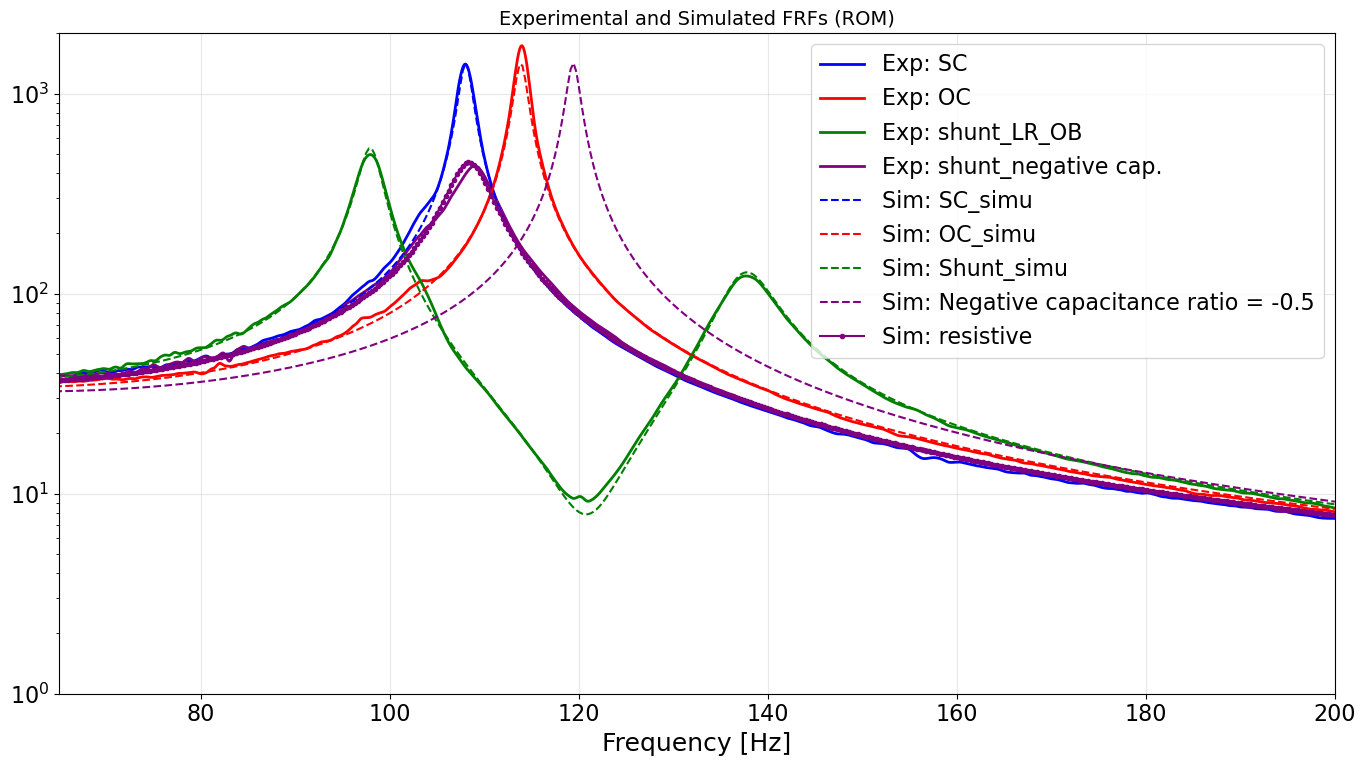


Plot complete. Experimental datasets: 4, Simulations: 5


In [247]:

# ============= ROM SETUP AND SIMULATION CASES =============
import importlib
from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module

importlib.reload(rom1_module)
ROM = rom1_module.ROM
L_b = 55e-3

params_rom = PiezoBeamParams(
    rho_p=7600,
    rho_s=8500,
    s11=14.5e-12,
    E_s=100e9,
    d31=-19.5e-11,
    eps_r=1700,
    b=31.75e-3,
    hp=0.275e-3,
    hs=0.128e-3,
    n_patches=1,
    w_p=L_b,
    omega_p=110 * 2 * np.pi,
    omega_q=200 * 2 * np.pi,
)
params_rom.L_b = L_b
params_rom.xL = np.array([0.0])
params_rom.xR = np.array([L_b])
no_modes = 1
rom = ROM(params=params_rom, N=no_modes, modal_damping_ratios=np.array([0.0065] * no_modes))

# Frequency sweep for ROM (same for all cases).
omega_rom = np.linspace(50, 200, 500)*2 * np.pi 

# Simulation cases: define control parameters and styling for each configuration (merged dictionary).


# Compute ROM responses for all simulation cases.
sim_frf_data = {}
for case_name, params in simulation_cases.items():
    try:
        ode_sys = rom.build_ode_system_base_excitation(
            a_base=lambda t: 1.0,
            j_exc=None,
            R_c=params["R_c"],
            K_p=params["K_p"],
            K_i=params["K_i"],
            K_c=params["K_c"],
            negative_capacitance_ratio=params.get("negative_capacitance_ratio", 0.0),
            base_accel_amp=1.0,
            freq_domain_amps=None,
        )
        
        freq_sim, rom_disp, rom_veloc = rom.frequency_response_fe3(
            ode_system=ode_sys,
            w=omega_rom,
            x_eval=np.linspace(0.0, params_rom.L_b, 20),
        )
        
        sim_frf_data[case_name] = {
            "freq": freq_sim,
            "mag": np.abs(rom_veloc[-1, :] 
             + 1/(1j*freq_sim*2*np.pi)
            ),
        }
        print(f"  computed: {case_name}")
    except Exception as e:
        print(f"  failed simulation: {case_name} -> {e}")

# ============= PLOTTING =============
plt.rcParams.update({
	"font.size": 9*2,
	"axes.labelsize": 9*2,
	"xtick.labelsize": 8*2,
	"ytick.labelsize": 8*2,
	"legend.fontsize": 8*2,
})
plt.figure(figsize=(14, 8))

# Plot all experimental FRFs.
for name, item in exp_frf_data.items():
    config = exp_datasets.get(name, {})
    style = {"color": config.get("color", "black"), "linestyle": config.get("linestyle", "-"), "linewidth": config.get("linewidth", 2), "marker": config.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"], label=f"Exp: {name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])

# Plot all simulation FRFs.
for case_name, item in sim_frf_data.items():
    params = simulation_cases.get(case_name, {})
    style = {"color": params.get("color", "gray"), "linestyle": params.get("linestyle", "--"), "linewidth": params.get("linewidth", 1.5),
             'marker': params.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"]*1000*8, label=f"Sim: {case_name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])

plt.xlim([65, 200])
plt.xlabel("Frequency [Hz]",)
# plt.ylabel("Magnitude", fontsize=12)
plt.ylim([1, 2e3])
plt.title("Experimental and Simulated FRFs (ROM)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend( loc="best")
plt.tight_layout()
plt.show()

print(f"\nPlot complete. Experimental datasets: {len(exp_frf_data)}, Simulations: {len(sim_frf_data)}")

In [248]:
print('Electromechanical coupling= ', (rom.p.theta_mech * rom.Gamma)[0,0])
print('C_p_eq= ', rom.p.Cp_scalar*1e9)
print('First natural frequency (undamped) = ', rom.omega/(2*np.pi))


Electromechanical coupling=  0.08980169717447302
C_p_eq=  157.85320482758618
First natural frequency (undamped) =  [108.03116588]


In [249]:
# -----------------------------
# Calibration from the nondimensional study
# -----------------------------
# Targets from Oueini_scipy_nondim.ipynb
mu1_bar_target = 6e-2
mu2_bar_target = 6.5e-3
k1_over_k2_target = 1.0
f2_bar_nominal = 1.5e-3
f2_bar_target_min = 0.5 * f2_bar_nominal
f2_bar_target_max = 2 * f2_bar_nominal

# Physical excitation range available in the experiment/simulation.
# Keep this explicit in base-acceleration units so the mapping is transparent.
a_base_values_g = np.linspace(5, 45, 20) * 1e-3
a_base_values = a_base_values_g * 9.81
a_base_min = a_base_values.min()
a_base_max = a_base_values.max()

theta_mech = float((rom.p.theta_mech * rom.Gamma)[0, 0])
sigma_r = float(rom.sigma_r)

# Use the same primary frequency scale already used in the physical notebook.
eps = 1
sigma2 = 0.0
freq_scale = 1
w1 = rom.omega[0] /2 
w2 = 2 * w1 - eps * sigma2

# Match the nondimensional damping targets.
mu1 = mu1_bar_target * w1
mu2 = mu2_bar_target * w1
mu1_bar_recovered = mu1 / w1
mu2_bar_recovered = mu2 / w1

# Base acceleration enters the modal equation through rom.sigma_r.
F2_values = sigma_r * a_base_values
F2_min = F2_values.min()
F2_max = F2_values.max()

# Calibrate k2 from the available physical forcing span to the target nondimensional span.
f2_bar_span_target = f2_bar_target_max - f2_bar_target_min
F2_span = F2_max - F2_min
if np.isclose(F2_span, 0.0):
    raise ValueError('Physical forcing span is zero; cannot calibrate k2 from the excitation range.')

k2 = f2_bar_nominal / F2_values[len(F2_values) //2] * (w1**4 / theta_mech)
k1 = k1_over_k2_target * k2
f1 = 0.0

# Diagnostics: mapped nondimensional forcing using the actual ODE input.
f2_bar_values = theta_mech * k2 * F2_values / (w1**4)
f2_bar_recovered_min = f2_bar_values.min()
f2_bar_recovered_max = f2_bar_values.max()

print('=== CALIBRATION SUMMARY ===')
print(f'theta_mech = {theta_mech:0.6e}')
print(f'rom.sigma_r = {sigma_r:0.6e}')
print(f'w1 / (2 pi) = {w1 / (2 * np.pi):0.6f} Hz')
print(f'w2 / (2 pi) = {w2 / (2 * np.pi):0.6f} Hz')
print()
print('Target nondimensional damping:')
print(f'  mu1_bar_target = {mu1_bar_target:0.6e}, recovered = {mu1_bar_recovered:0.6e}')
print(f'  mu2_bar_target = {mu2_bar_target:0.6e}, recovered = {mu2_bar_recovered:0.6e}')
print()
print('Target nondimensional forcing range:')
print(f'  target f2_bar range = [{f2_bar_target_min:0.6e}, {f2_bar_target_max:0.6e}]')
print(f'  recovered f2_bar range = [{f2_bar_recovered_min:0.6e}, {f2_bar_recovered_max:0.6e}]')
print()
print('Physical excitation range:')
print(f'  a_base range [g] = [{a_base_values_g.min():0.6f}, {a_base_values_g.max():0.6f}]')
print(f'  a_base range [m/s^2] = [{a_base_min:0.6e}, {a_base_max:0.6e}]')
print(f'  modal forcing range F2 = sigma_r * a_base = [{F2_min:0.6e}, {F2_max:0.6e}]')
print()
print('Recovered dimensional parameters:')
print(f'  mu1 = {mu1:0.6e}')
print(f'  mu2 = {mu2:0.6e}')
print(f'  k1 = {k1:0.6e}')
print(f'  k2 = {k2:0.6e}')
print(f'  k1 / k2 = {k1 / k2:0.6e}')

if not np.isclose(f2_bar_recovered_min, f2_bar_target_min, rtol=1e-2, atol=1e-12):
    print('WARNING: span matching reproduces the nondimensional forcing span exactly, but not the lower endpoint.')


=== CALIBRATION SUMMARY ===
theta_mech = 8.980170e-02
rom.sigma_r = 7.509887e-02
w1 / (2 pi) = 54.015583 Hz
w2 / (2 pi) = 108.031166 Hz

Target nondimensional damping:
  mu1_bar_target = 6.000000e-02, recovered = 6.000000e-02
  mu2_bar_target = 6.500000e-03, recovered = 6.500000e-03

Target nondimensional forcing range:
  target f2_bar range = [7.500000e-04, 3.000000e-03]
  recovered f2_bar range = [2.878788e-04, 2.590909e-03]

Physical excitation range:
  a_base range [g] = [0.005000, 0.045000]
  a_base range [m/s^2] = [4.905000e-02, 4.414500e-01]
  modal forcing range F2 = sigma_r * a_base = [3.683600e-03, 3.315240e-02]

Recovered dimensional parameters:
  mu1 = 2.036340e+01
  mu2 = 2.206034e+00
  k1 = 1.154645e+10
  k2 = 1.154645e+10
  k1 / k2 = 1.000000e+00


C:\Users\setemadi3\AppData\Local\Temp\ipykernel_18972\3410898623.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_r = float(rom.sigma_r)


In [233]:
import time
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# -----------------------------
# Physical sweep using the calibrated parameters
# -----------------------------
freq_ratio_values = np.linspace(0.98, 1.02, 30)
samples_per_period = 100
n_periods_total = 500
n_periods_transient = n_periods_total - 100

omega_exc_values = freq_ratio_values * w2

rtol = 1e-8
atol = 1e-9

print('=== PHYSICAL SWEEP SETUP ===')
print(f'Electromechanical coupling theta_mech = {theta_mech:0.6e}')
print(f'C_p_eq = {rom.p.Cp_scalar * 1e9:0.6f} nF')
print(f'First natural frequency (ROM undamped) = {rom.omega / (2 * np.pi)} Hz')
print(f'2 mu1 = {2 * mu1:0.6e}')
print(f'2 mu2 = {2 * mu2:0.6e}')

def rhs(t, y, F2_amp, omega_exc):
    u1, v1, u2, v2 = y
    F1 = eps * f1 * np.cos(omega_exc * t)
    F2 = F2_amp * np.cos(omega_exc * t)

    du1 = v1
    dv1 = -w1**2 * u1 - 2 * mu1 * v1 + k1 * u1 * u2
    du2 = v2
    dv2 = -w2**2 * u2 - 2 * mu2 * v2 + theta_mech * k2 * u1**2 + F2

    return np.array([du1, dv1, du2, dv2])

def run_case_ivp(F2_amp, omega_exc, y0=None):
    dt = 2 * pi / (samples_per_period * omega_exc)
    t_end = n_periods_total * 2 * pi / omega_exc
    t_trans = n_periods_transient * 2 * pi / omega_exc

    n_steps = int(np.round(t_end / dt))
    t_eval = np.linspace(0.0, n_steps * dt, n_steps + 1)

    if y0 is None:
        y0 = np.array([0.0, 1e-3, 0.0, 0.0])

    t0 = time.perf_counter()
    sol = solve_ivp(
        rhs,
        [0.0, t_eval[-1]],
        y0,
        args=(F2_amp, omega_exc),
        t_eval=t_eval,
        method='RK45',
        rtol=rtol,
        atol=atol,
    )
    runtime = time.perf_counter() - t0

    mask = sol.t >= t_trans
    u1 = sol.y[0]
    u2 = sol.y[2]
    v2 = sol.y[3]

    a1_rms = np.sqrt(np.mean(u1[mask] ** 2))
    a2_rms = np.sqrt(np.mean(u2[mask] ** 2))
    v2_rms = np.sqrt(np.mean(v2[mask] ** 2))

    return {
        't': sol.t,
        'y': sol.y,
        'a1_rms': a1_rms,
        'a2_rms': a2_rms,
        'v2_rms': v2_rms,
        'runtime_s': runtime,
    }

def run_amplitude_column(j, F2_amp):
    """One amplitude column: keep frequency continuation sequential inside each worker."""
    y0_col = np.array([0.0, 1e-4, 0.0, 0.0])
    col_a1 = np.zeros(len(freq_ratio_values))
    col_a2 = np.zeros(len(freq_ratio_values))
    col_v2 = np.zeros(len(freq_ratio_values))
    col_runtime = np.zeros(len(freq_ratio_values))

    for i, omega_exc in enumerate(omega_exc_values):
        out = run_case_ivp(F2_amp, omega_exc, y0=y0_col)
        col_a1[i] = out['a1_rms']
        col_a2[i] = out['a2_rms']
        col_v2[i] = out['v2_rms']
        col_runtime[i] = out['runtime_s']
        y0_col = out['y'][:, -1].copy()

    return j, col_a1, col_a2, col_v2, col_runtime

A1 = np.zeros((len(freq_ratio_values), len(F2_values)))
A2 = np.zeros((len(freq_ratio_values), len(F2_values)))
V2_RMS = np.zeros((len(freq_ratio_values), len(F2_values)))
RUNTIME = np.zeros((len(freq_ratio_values), len(F2_values)))

n_jobs = -1  # use all cores
t_sweep_start = time.perf_counter()
if HAS_JOBLIB:
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=12)(
        delayed(run_amplitude_column)(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    )
else:
    print('joblib not found, running sequential sweep.')
    results = [
        run_amplitude_column(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    ]
t_sweep_total = time.perf_counter() - t_sweep_start

for j, col_a1, col_a2, col_v2, col_runtime in results:
    A1[:, j] = col_a1
    A2[:, j] = col_a2
    V2_RMS[:, j] = col_v2
    RUNTIME[:, j] = col_runtime

print('Sweep completed (parallel over excitation-amplitude columns when joblib is available).')
print(f'Grid size: {A1.shape[0]} frequency points x {A1.shape[1]} amplitude points')
print(f'Average runtime per case: {np.mean(RUNTIME):.3f} s')
print(f'Total wall time: {t_sweep_total:.3f} s')

=== PHYSICAL SWEEP SETUP ===
Electromechanical coupling theta_mech = 8.980170e-02
C_p_eq = 157.853205 nF
First natural frequency (ROM undamped) = [108.03116588] Hz
2 mu1 = 4.072679e+01
2 mu2 = 4.412069e+00


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done   3 out of  20 | elapsed:  1.9min remaining: 10.7min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  2.0min remaining:  6.0min
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  2.1min remaining:  3.9min
[Parallel(n_jobs=-1)]: Done   9 out of  20 | elapsed:  2.1min remaining:  2.6min
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:  2.2min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:  2.2min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  15 out of  20 | elapsed:  2.2min remaining:   43.8s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  2.8min remaining:   29.7s


Sweep completed (parallel over excitation-amplitude columns when joblib is available).
Grid size: 30 frequency points x 20 amplitude points
Average runtime per case: 3.524 s
Total wall time: 190.516 s


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  3.2min finished


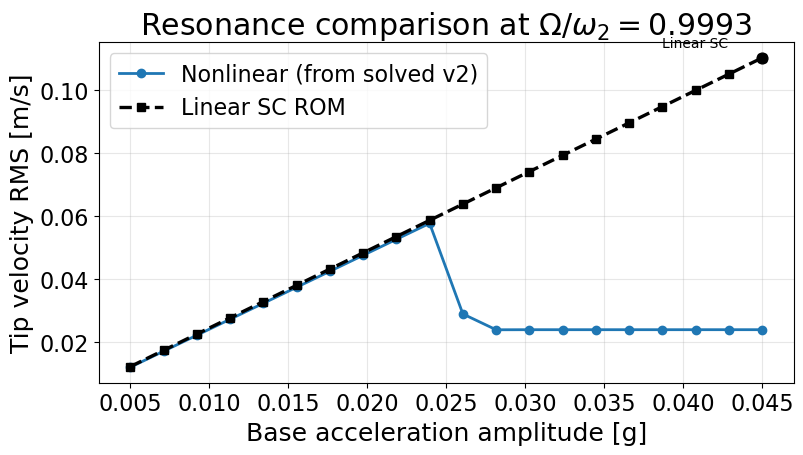

=== Resonance Velocity Comparison Summary ===
omega_res/(2*pi) = 107.956662 Hz
phi_tip (retained structural mode) = 2.085230e+01
Linear SC gain (tip peak velocity / base accel) = 1.764588e-01 (m/s)/(m/s^2)
Linear SC curve is the black dashed line with square markers.
Note: linear curve converted peak->RMS with 1/sqrt(2).


In [234]:
# --- Resonance comparison: nonlinear vs linear SC in LDV tip-velocity RMS ---

# Resonance index consistent with cell-12 sweep definition.
idx_res = int(np.argmin(np.abs(freq_ratio_values - 1.00)))
omega_res = float(omega_exc_values[idx_res])

# Single retained structural mode shape at tip (x = L_b).
phi_tip = float(np.abs(rom.mode_shape(0, rom.p.L_b)))

# Nonlinear structural velocity RMS from direct solved derivative state (v2), then map to tip.
v_struct_rms_nl = V2_RMS[idx_res, :]
v_tip_rms_nl = phi_tip * v_struct_rms_nl

# Linear SC tip-velocity RMS at the same resonance frequency.
sc_params = {
    'R_c': 1e4,
    'K_p': 100000,
    'K_i': 0.0,
    'K_c': 0.0,
    'negative_capacitance_ratio': 0.0,
}

ode_sc = rom.build_ode_system_base_excitation(
    a_base=lambda t: 1.0,
    j_exc=None,
    R_c=sc_params['R_c'],
    K_p=sc_params['K_p'],
    K_i=sc_params['K_i'],
    K_c=sc_params['K_c'],
    negative_capacitance_ratio=sc_params['negative_capacitance_ratio'],
    base_accel_amp=1.0,
    freq_domain_amps=None,
)

# x_eval at tip only; velocity output is complex peak amplitude in frequency domain.
_, _, v_sc_tip = rom.frequency_response_fe3(
    ode_system=ode_sc,
    w=np.array([omega_res]),
    x_eval=np.array([rom.p.L_b]),
)

v_tip_peak_per_acc = float(np.abs(v_sc_tip[0, 0]))  # (m/s) per (m/s^2)
v_tip_rms_lin = (v_tip_peak_per_acc * a_base_values) / np.sqrt(2.0) * 2

fig, ax = plt.subplots(figsize=(8.4, 4.9))
ax.plot(
    a_base_values_g,
    v_tip_rms_nl,
    color='tab:blue',
    marker='o',
    lw=2.0,
    ms=6,
    label='Nonlinear (from solved v2)',
    zorder=3,
)
ax.plot(
    a_base_values_g,
    v_tip_rms_lin,
    color='black',
    marker='s',
    ls='--',
    lw=2.4,
    ms=6,
    label='Linear SC ROM',
    zorder=4,
)

# Mark the linear curve endpoint to make it unambiguous.
ax.scatter(a_base_values_g[-1], v_tip_rms_lin[-1], color='black', s=60, zorder=5)
ax.annotate(
    'Linear SC',
    xy=(a_base_values_g[-1], v_tip_rms_lin[-1]),
    xytext=(-72, 8),
    textcoords='offset points',
    fontsize=10,
    color='black',
)

ax.set_xlabel('Base acceleration amplitude [g]')
ax.set_ylabel('Tip velocity RMS [m/s]')
ax.set_title(f'Resonance comparison at $\\Omega/\\omega_2={freq_ratio_values[idx_res]:.4f}$')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.show()

print('=== Resonance Velocity Comparison Summary ===')
print(f'omega_res/(2*pi) = {omega_res/(2*np.pi):.6f} Hz')
print(f'phi_tip (retained structural mode) = {phi_tip:.6e}')
print(f'Linear SC gain (tip peak velocity / base accel) = {v_tip_peak_per_acc:.6e} (m/s)/(m/s^2)')
print('Linear SC curve is the black dashed line with square markers.')
print('Note: linear curve converted peak->RMS with 1/sqrt(2).')

In [235]:
import pandas as pd

# --- LabVIEW FPGA FXP range audit for the first equation (q = u1, y = u2) ---
beta = w1**2
mu_ctrl = 2 * mu1 / beta
K_f = k1 / beta
fxp_margin = 1.25
fxp_rel_resolution = 1e-3
fxp_min_frac_bits = 12
fxp_max_frac_bits = 30

wire_definitions = {
    'u1': {
        'expr': r'$q = u_1$',
        'meaning': 'second integrator output / controller state',
        'units': 'model displacement-like state',
        'signal': lambda u1, v1, u2, dv1: u1,
    },
    'u1_dot': {
        'expr': r'$\dot{q} = \dot{u}_1$',
        'meaning': 'first integrator output',
        'units': 'model velocity-like state',
        'signal': lambda u1, v1, u2, dv1: v1,
    },
    'u2': {
        'expr': r'$y = u_2$',
        'meaning': 'measured multiplicative input to controller',
        'units': 'model displacement-like state',
        'signal': lambda u1, v1, u2, dv1: u2,
    },
    'Kf*u2*u1': {
        'expr': r'$p = K_f u_2 u_1$',
        'meaning': 'product block output',
        'units': 'controller summer input',
        'signal': lambda u1, v1, u2, dv1: K_f * u2 * u1,
    },
    '-u1': {
        'expr': r'$-q = -u_1$',
        'meaning': 'negative position feedback into summer',
        'units': 'controller summer input',
        'signal': lambda u1, v1, u2, dv1: -u1,
    },
    '-mu*u1_dot': {
        'expr': r'$d = -\mu \dot{u}_1$',
        'meaning': 'damping feedback into summer',
        'units': 'controller summer input',
        'signal': lambda u1, v1, u2, dv1: -mu_ctrl * v1,
    },
    'summer': {
        'expr': r'$s = K_f u_2 u_1 - u_1 - \mu \dot{u}_1$',
        'meaning': 'controller summer output before beta gain',
        'units': 'controller acceleration command / beta',
        'signal': lambda u1, v1, u2, dv1: K_f * u2 * u1 - u1 - mu_ctrl * v1,
    },
    'beta*summer': {
        'expr': r'$a = \beta s = \ddot{u}_1$',
        'meaning': 'beta gain output / first-equation acceleration',
        'units': 'model acceleration-like state',
        'signal': lambda u1, v1, u2, dv1: beta * (K_f * u2 * u1 - u1 - mu_ctrl * v1),
    },
}

def recommend_fxp(max_abs_with_margin, steady_peak):
    signed = True
    safe_mag = max(float(max_abs_with_margin), 1e-15)
    # Signed LabVIEW-style integer word length heuristic.
    integer_word_length = int(np.ceil(np.log2(safe_mag + 1e-30)) + 1)
    resolution_target = max(float(steady_peak) * fxp_rel_resolution, safe_mag * 2**(-20), 1e-12)
    frac_bits = int(np.ceil(-np.log2(resolution_target)))
    frac_bits = int(np.clip(frac_bits, fxp_min_frac_bits, fxp_max_frac_bits))
    word_length = int(integer_word_length + frac_bits)
    return signed, word_length, integer_word_length, frac_bits

def quantize_signed_fixed(values, integer_word_length, frac_bits):
    values = np.asarray(values, dtype=float)
    scale = 2.0 ** frac_bits
    min_val = -(2.0 ** (integer_word_length - 1))
    max_val = (2.0 ** (integer_word_length - 1)) - (1.0 / scale)
    clipped = np.clip(values, min_val, max_val)
    quantized = np.round(clipped * scale) / scale
    overflow_count = int(np.count_nonzero((values < min_val) | (values > max_val)))
    return quantized, min_val, max_val, overflow_count

def run_audit_amplitude_column(j, F2_amp):
    y0_col = np.array([0.0, 1e-4, 0.0, 0.0])
    column_buffers = {name: [] for name in wire_definitions}
    column_buffers['u1_ddot_rhs'] = []
    column_case_log = []

    for i, omega_exc in enumerate(omega_exc_values):
        out = run_case_ivp(F2_amp, omega_exc, y0=y0_col)
        y0_col = out['y'][:, -1].copy()
        t = out['t']
        u1 = out['y'][0]
        v1 = out['y'][1]
        u2 = out['y'][2]
        dv1_rhs = -w1**2 * u1 - 2 * mu1 * v1 + k1 * u1 * u2
        steady_mask = t >= (n_periods_transient * 2 * np.pi / omega_exc)
        if not np.any(steady_mask):
            steady_mask = np.ones_like(t, dtype=bool)

        metadata = {
            'freq_ratio': float(freq_ratio_values[i]),
            'omega_exc_hz': float(omega_exc / (2 * np.pi)),
            'a_base_g': float(a_base_values_g[j]),
            'f2_bar': float(f2_bar_values[j]),
        }

        for name, spec in wire_definitions.items():
            signal = np.asarray(spec['signal'](u1, v1, u2, dv1_rhs), dtype=float)
            column_buffers[name].append({
                'all': signal,
                'steady': signal[steady_mask],
                **metadata,
            })

        column_buffers['u1_ddot_rhs'].append({
            'all': dv1_rhs,
            'steady': dv1_rhs[steady_mask],
            **metadata,
        })
        column_case_log.append({
            **metadata,
            'n_samples': int(len(t)),
            'n_steady': int(np.count_nonzero(steady_mask)),
        })

    return j, column_buffers, column_case_log

audit_buffers = {name: [] for name in wire_definitions}
audit_buffers['u1_ddot_rhs'] = []
audit_case_log = []

audit_n_jobs = -1
audit_start = time.perf_counter()
if HAS_JOBLIB:
    audit_results = Parallel(n_jobs=audit_n_jobs, backend='loky', verbose=12)(
        delayed(run_audit_amplitude_column)(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    )
else:
    print('joblib not found, running FXP audit sequentially.')
    audit_results = [
        run_audit_amplitude_column(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    ]
audit_wall_time = time.perf_counter() - audit_start

for j, column_buffers, column_case_log in audit_results:
    for name in audit_buffers:
        audit_buffers[name].extend(column_buffers[name])
    audit_case_log.extend(column_case_log)

audit_rows = []
verification_rows = []

for name, spec in wire_definitions.items():
    entries = audit_buffers[name]
    all_values = np.concatenate([entry['all'] for entry in entries])
    steady_values = np.concatenate([entry['steady'] for entry in entries])
    abs_all = np.abs(all_values)
    abs_steady = np.abs(steady_values)
    peak_idx = int(np.argmax(abs_all))
    peak_case = next(entry for entry in entries if np.max(np.abs(entry['all'])) == np.max(abs_all))

    min_val = float(np.min(all_values))
    max_val = float(np.max(all_values))
    max_abs = float(np.max(abs_all))
    transient_peak = float(np.max(abs_all))
    steady_peak = float(np.max(abs_steady))
    design_max = float(fxp_margin * max_abs)

    signed, wl, iwl, frac_bits = recommend_fxp(design_max, steady_peak)
    quantized, q_min, q_max, overflow_count = quantize_signed_fixed(all_values, iwl, frac_bits)
    quant_error = quantized - all_values

    audit_rows.append({
        'wire_name': name,
        'expression': spec['expr'],
        'physical_meaning': spec['meaning'],
        'units': spec['units'],
        'min': min_val,
        'max': max_val,
        'max_abs': max_abs,
        'transient_peak_abs': transient_peak,
        'steady_peak_abs': steady_peak,
        'design_margin': fxp_margin,
        'design_max_abs': design_max,
        'required_signed_range': f'[{ -design_max:0.6e}, {design_max:0.6e}]',
        'proposed_fxp': f'signed <{wl},{iwl}> (frac={frac_bits})',
        'quant_range': f'[{q_min:0.6e}, {q_max:0.6e}]',
        'overflow_count': overflow_count,
        'quant_max_abs_error': float(np.max(np.abs(quant_error))),
        'quant_rms_error': float(np.sqrt(np.mean(quant_error**2))),
        'worst_case_freq_ratio': peak_case['freq_ratio'],
        'worst_case_a_base_g': peak_case['a_base_g'],
        'worst_case_f2_bar': peak_case['f2_bar'],
        'notes': 'round-to-nearest, saturate on overflow',
    })

beta_summer_entries = audit_buffers['beta*summer']
rhs_entries = audit_buffers['u1_ddot_rhs']
for beta_entry, rhs_entry in zip(beta_summer_entries, rhs_entries):
    residual = beta_entry['all'] - rhs_entry['all']
    verification_rows.append({
        'freq_ratio': beta_entry['freq_ratio'],
        'a_base_g': beta_entry['a_base_g'],
        'f2_bar': beta_entry['f2_bar'],
        'max_abs_residual': float(np.max(np.abs(residual))),
        'rms_residual': float(np.sqrt(np.mean(residual**2))),
    })

fxp_audit_table = pd.DataFrame(audit_rows)
fxp_verification_table = pd.DataFrame(verification_rows)
fxp_case_table = pd.DataFrame(audit_case_log)
controller_param_rows = [
    {
        'parameter': 'beta',
        'expression': r'$\beta = \omega_1^2$',
        'meaning': 'controller gain before the double integrator / natural-frequency-squared term',
        'value': float(beta),
        'units': '1/s^2',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': 'signed scalar constant; choose from exact compile-time value if possible',
        'notes': 'not a runtime-varying wire in this controller implementation',
    },
    {
        'parameter': 'mu_ctrl',
        'expression': r'$\mu = 2\mu_1/\beta$',
        'meaning': 'controller damping coefficient multiplying qdot in the summer',
        'value': float(mu_ctrl),
        'units': 's',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': 'signed scalar constant; resolution should keep -mu*qdot quantization below q-path resolution',
        'notes': 'small coefficient, so prioritize fractional precision over integer range',
    },
    {
        'parameter': 'K_f',
        'expression': r'$K_f = k_1/\beta$',
        'meaning': 'controller nonlinear product gain multiplying u2*q',
        'value': float(K_f),
        'units': '1/(state units of u2)',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': 'signed scalar constant; resolution should keep K_f*u2*u1 quantization below summer resolution',
        'notes': 'specify together with the expected runtime range of u2*q',
    },
]
controller_param_table = pd.DataFrame(controller_param_rows)

display_columns = [
    'wire_name',
    'expression',
    'units',
    'min',
    'max',
    'max_abs',
    'transient_peak_abs',
    'steady_peak_abs',
    'design_max_abs',
    'required_signed_range',
    'proposed_fxp',
    'overflow_count',
    'quant_max_abs_error',
    'worst_case_freq_ratio',
    'worst_case_a_base_g',
]

print('=== LABVIEW CONTROLLER PARAMETER MAPPING ===')
print(f'beta = omega_1^2 = {beta:0.6e}')
print(f'mu_ctrl = 2 * mu1 / beta = {mu_ctrl:0.6e}')
print(f'K_f = k1 / beta = {K_f:0.6e}')
print(f'FXP audit wall time = {audit_wall_time:0.3f} s')
print()
print('=== CONTROLLER PARAMETER SPECS ===')
display(controller_param_table)
print()
print('=== FXP RANGE AUDIT TABLE ===')
display(fxp_audit_table[display_columns])
print()
print('=== beta * summer vs. first-equation acceleration consistency ===')
display(fxp_verification_table)
print(f'max verification residual across all cases = {fxp_verification_table["max_abs_residual"].max():0.6e}')
print()
print('=== Audited operating envelope ===')
display(fxp_case_table.drop_duplicates()[['freq_ratio', 'omega_exc_hz', 'a_base_g', 'f2_bar']])


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   3 out of  20 | elapsed:  1.8min remaining: 10.0min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  1.9min remaining:  5.7min
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  1.9min remaining:  3.6min
[Parallel(n_jobs=-1)]: Done   9 out of  20 | elapsed:  2.0min remaining:  2.4min
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:  2.0min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:  2.0min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  15 out of  20 | elapsed:  2.0min remaining:   40.5s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  2.9min remaining:   30.3s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  3.0min finished


=== LABVIEW CONTROLLER PARAMETER MAPPING ===
beta = omega_1^2 = 1.151855e+05
mu_ctrl = 2 * mu1 / beta = 3.535756e-04
K_f = k1 / beta = 1.002422e+05
FXP audit wall time = 179.163 s

=== CONTROLLER PARAMETER SPECS ===


,parameter,expression,meaning,value,units,proposed_storage,recommended_fxp,notes
0,beta,$\beta = \omega_1^2$,controller gain before the double integrator /...,115185.515828,1/s^2,constant / host-to-FPGA control,signed scalar constant; choose from exact comp...,not a runtime-varying wire in this controller ...
1,mu_ctrl,$\mu = 2\mu_1/\beta$,controller damping coefficient multiplying qdo...,0.000354,s,constant / host-to-FPGA control,signed scalar constant; resolution should keep...,"small coefficient, so prioritize fractional pr..."
2,K_f,$K_f = k_1/\beta$,controller nonlinear product gain multiplying ...,100242.195731,1/(state units of u2),constant / host-to-FPGA control,signed scalar constant; resolution should keep...,specify together with the expected runtime ran...



=== FXP RANGE AUDIT TABLE ===


,wire_name,expression,units,min,max,max_abs,transient_peak_abs,steady_peak_abs,design_max_abs,required_signed_range,proposed_fxp,overflow_count,quant_max_abs_error,worst_case_freq_ratio,worst_case_a_base_g
0,u1,$q = u_1$,model displacement-like state,-0.000019,0.000018,0.000019,0.000019,0.000015,0.000023,"[-2.349485e-05, 2.349485e-05]","signed <12,-14> (frac=26)",0,7.450578e-09,0.997931,0.030263
1,u1_dot,$\dot{q} = \dot{u}_1$,model velocity-like state,-0.006209,0.006277,0.006277,0.006277,0.005349,0.007846,"[-7.845972e-03, 7.845972e-03]","signed <13,-5> (frac=18)",0,1.907348e-06,0.999310,0.026053
2,u2,$y = u_2$,model displacement-like state,-0.000006,0.000006,0.000006,0.000006,0.000006,0.000008,"[-7.837878e-06, 7.837878e-06]","signed <13,-15> (frac=28)",0,1.862645e-09,0.999310,0.026053
3,Kf*u2*u1,$p = K_f u_2 u_1$,controller summer input,-0.000006,0.000006,0.000006,0.000006,0.000005,0.000007,"[-6.985594e-06, 6.985594e-06]","signed <12,-16> (frac=28)",0,1.862645e-09,0.997931,0.030263
4,-u1,$-q = -u_1$,controller summer input,-0.000018,0.000019,0.000019,0.000019,0.000015,0.000023,"[-2.349485e-05, 2.349485e-05]","signed <12,-14> (frac=26)",0,7.450578e-09,0.997931,0.030263
5,-mu*u1_dot,$d = -\mu \dot{u}_1$,controller summer input,-0.000002,0.000002,0.000002,0.000002,0.000002,0.000003,"[-2.774145e-06, 2.774145e-06]","signed <12,-17> (frac=29)",0,9.313226e-10,0.999310,0.026053
6,summer,$s = K_f u_2 u_1 - u_1 - \mu \dot{u}_1$,controller acceleration command / beta,-0.000020,0.000020,0.000020,0.000020,0.000017,0.000025,"[-2.528908e-05, 2.528908e-05]","signed <12,-14> (frac=26)",0,7.450580e-09,0.999310,0.026053
7,beta*summer,$a = \beta s = \ddot{u}_1$,model acceleration-like state,-2.320093,2.330349,2.330349,2.330349,2.004800,2.912936,"[-2.912936e+00, 2.912936e+00]","signed <15,3> (frac=12)",0,1.220703e-04,0.999310,0.026053



=== beta * summer vs. first-equation acceleration consistency ===


,freq_ratio,a_base_g,f2_bar,max_abs_residual,rms_residual
0,0.980000,0.005,0.000288,6.938894e-18,1.861670e-19
1,0.981379,0.005,0.000288,1.991365e-59,5.080471e-61
2,0.982759,0.005,0.000288,2.857468e-101,1.137433e-102
3,0.984138,0.005,0.000288,1.640106e-142,3.601235e-144
4,0.985517,0.005,0.000288,4.706875e-184,0.000000e+00
...,...,...,...,...,...
595,1.014483,0.045,0.002591,2.220446e-16,2.021143e-17
596,1.015862,0.045,0.002591,6.938894e-18,5.262291e-19
597,1.017241,0.045,0.002591,5.293956e-23,2.241389e-24
598,1.018621,0.045,0.002591,9.860761e-32,3.961882e-33


max verification residual across all cases = 8.881784e-16

=== Audited operating envelope ===


,freq_ratio,omega_exc_hz,a_base_g,f2_bar
0,0.980000,105.870543,0.005,0.000288
1,0.981379,106.019551,0.005,0.000288
2,0.982759,106.168560,0.005,0.000288
3,0.984138,106.317568,0.005,0.000288
4,0.985517,106.466577,0.005,0.000288
...,...,...,...,...
595,1.014483,109.595755,0.045,0.002591
596,1.015862,109.744764,0.045,0.002591
597,1.017241,109.893772,0.045,0.002591
598,1.018621,110.042781,0.045,0.002591


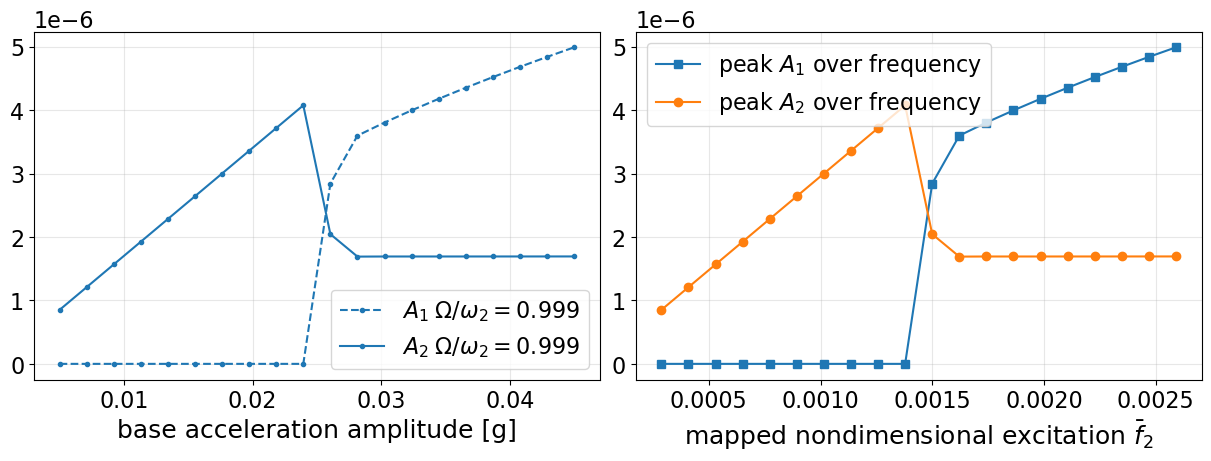

In [236]:

# ---- Amplitude vs excitation amplitude study ----
# 1) Fixed-frequency slices (near resonance).
target_ratios = [1.00]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for idx in idxs:
    r = freq_ratio_values[idx]
    l1, = axs[0].plot(a_base_values_g, A1[idx, :], '.--', label=fr"$A_1 \; \Omega/\omega_2={r:.3f}$")
    axs[0].plot(a_base_values_g, A2[idx, :], '.-', color=l1.get_color(),label=fr"$A_2 \; \Omega/\omega_2={r:.3f}$")

axs[0].set_xlabel(r"base acceleration amplitude [g]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()
idx = idxs[0]  # index for ratio closest to 1.00

axs[1].plot(f2_bar_values, A1[idx, :], "-s", label=r"peak $A_1$ over frequency")
axs[1].plot(f2_bar_values, A2[idx, :], "-o", label=r"peak $A_2$ over frequency")
axs[1].set_xlabel(r"mapped nondimensional excitation $\bar{f}_2$")
axs[1].grid(True, alpha=0.3)
axs[1].legend()



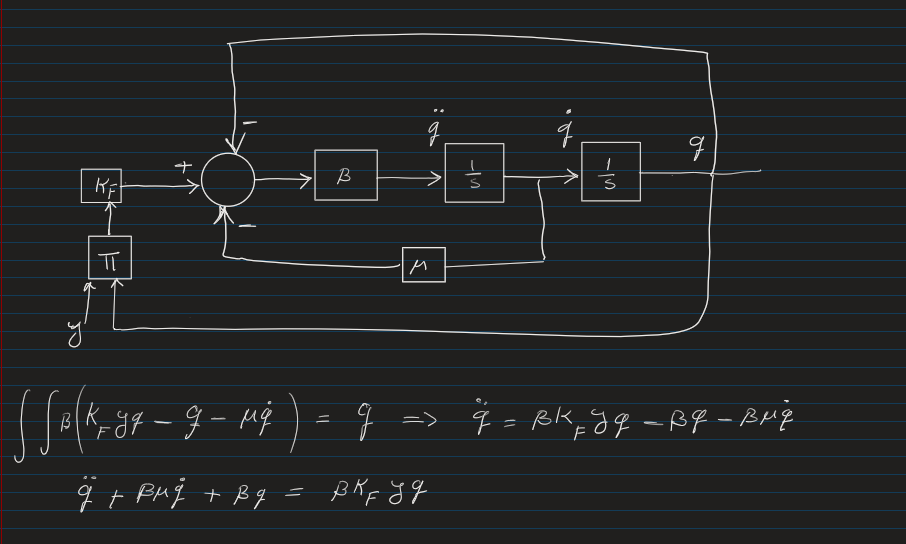

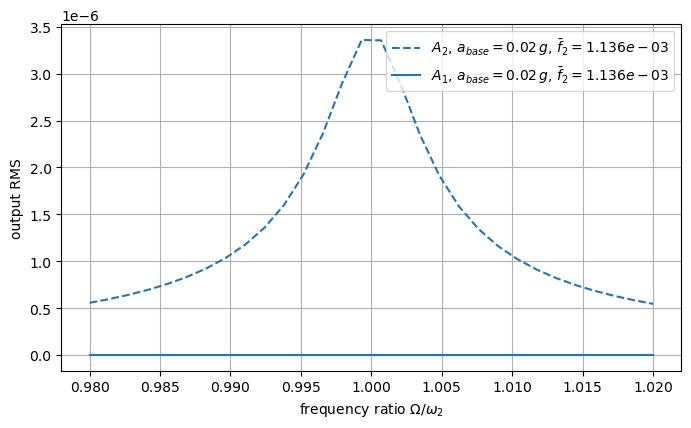

In [237]:
# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# extent = [f2_values[0], f2_values[-1], freq_ratio_values[0], freq_ratio_values[-1]]

# im0 = axs[0].imshow(A1, origin="lower", aspect="auto", extent=extent)
# axs[0].set_title(r"$A_1$ RMS (solve_ivp)")
# axs[0].set_xlabel(r"forcing amplitude $f_2$")
# axs[0].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im0, ax=axs[0], label="RMS")

# im1 = axs[1].imshow(A2, origin="lower", aspect="auto", extent=extent)
# axs[1].set_title(r"$A_2$ RMS (solve_ivp)")
# axs[1].set_xlabel(r"forcing amplitude $f_2$")
# axs[1].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im1, ax=axs[1], label="RMS")

# im2 = axs[2].imshow(RUNTIME, origin="lower", aspect="auto", extent=extent)
# axs[2].set_title("Runtime per case [s] (solve_ivp)")
# axs[2].set_xlabel(r"forcing amplitude $f_2$")
# axs[2].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im2, ax=axs[2], label="s")

# plt.show()
plt.rcdefaults()
pick_js = [0, len(a_base_values) // 2, len(a_base_values) - 1]
pick_js = [7]
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    label_a2 = fr"$A_2$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    label_a1 = fr"$A_1$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    l1, = plt.plot(freq_ratio_values, A2[:, j], "--",  label=label_a2)
    plt.plot(freq_ratio_values, A1[:, j], "-", color=l1.get_color(), label=label_a1)
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"output RMS")
# plt.title(r"$A_2$ frequency response slices (solve_ivp)")
plt.grid(True)
plt.legend()
plt.show()


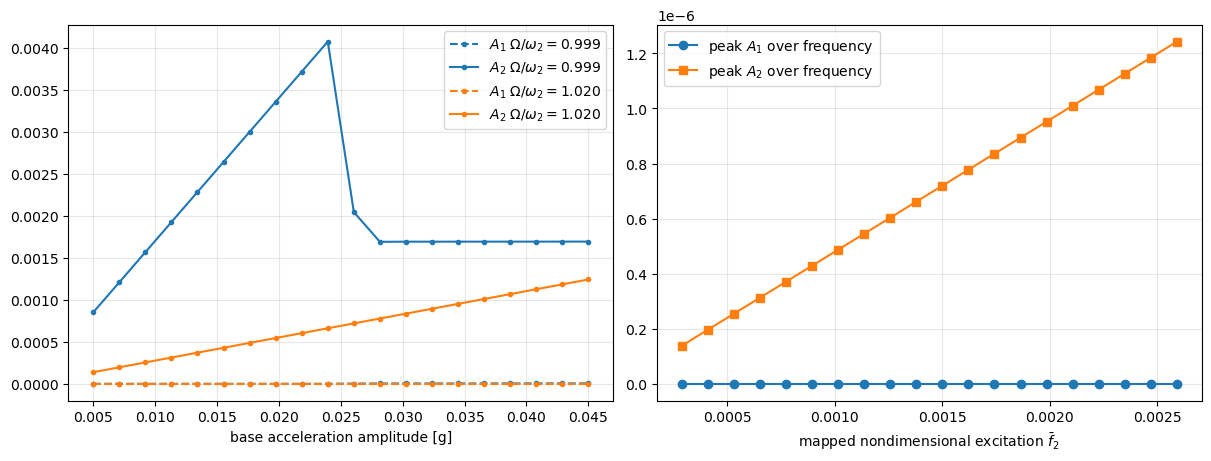

In [238]:

# ---- Amplitude vs excitation amplitude study ----
# 1) Fixed-frequency slices (near resonance).
target_ratios = [1.00, 1.02]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for idx in idxs:
    r = freq_ratio_values[idx]
    l1, = axs[0].plot(a_base_values_g, A1[idx, :], '.--', label=fr"$A_1 \; \Omega/\omega_2={r:.3f}$")
    axs[0].plot(a_base_values_g, A2[idx, :]*1000, '.-', color=l1.get_color(),label=fr"$A_2 \; \Omega/\omega_2={r:.3f}$")

axs[0].set_xlabel(r"base acceleration amplitude [g]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()
idx = idxs[1]  # index for ratio closest to 1.00

axs[1].plot(f2_bar_values, A1[idx, :], "-o", label=r"peak $A_1$ over frequency")
axs[1].plot(f2_bar_values, A2[idx, :], "-s", label=r"peak $A_2$ over frequency")
axs[1].set_xlabel(r"mapped nondimensional excitation $\bar{f}_2$")
axs[1].grid(True, alpha=0.3)
axs[1].legend()



In [239]:
rom.sigma_r * 30e-3*9.8
w1
rom.omega[0]

np.float64(678.7798341960588)